In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
#Calculating LTI 

df = pd.read_csv("credit_risk_dataset.csv")
df['loan_int_rate'] = df['loan_int_rate'].fillna(0)
df['person_emp_length'] = df['person_emp_length'].fillna(0)
df['LTI'] = np.round(df['loan_amnt'] / df['person_income'],2)
df[['loan_amnt', 'person_income', 'LTI']]



,loan_amnt,person_income,LTI
0,35000,59000,0.59
1,1000,9600,0.10
2,5500,9600,0.57
3,35000,65500,0.53
4,35000,54400,0.64
...,...,...,...
32576,5800,53000,0.11
32577,17625,120000,0.15
32578,35000,76000,0.46
32579,15000,150000,0.10


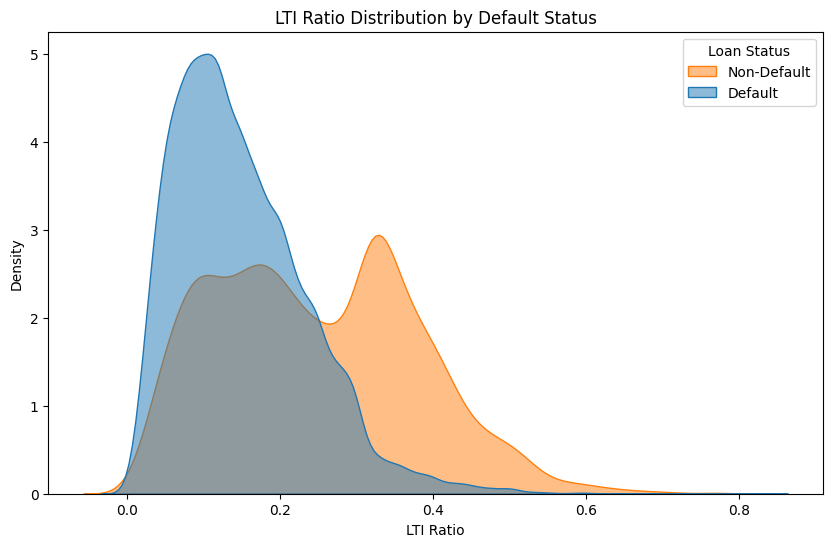

In [ ]:
#LTI ratio distribution by default status
plt.figure(figsize=(10, 6))

sns.kdeplot(data=df, x='LTI', hue='loan_status', fill=True, alpha=0.5, common_norm=False)

plt.title('LTI Ratio Distribution by Default Status')
plt.xlabel('LTI Ratio')
plt.ylabel('Density')
plt.legend(title='Loan Status', labels=['Non-Default', 'Default'])
plt.show()

Observation: For defaulted loans, LTI ratios are primarily on the lower end instead of the higher end like what is expected. Normally, the intuintion is that higher LTI ratios will lead to a higher default rate since borrowing much more than the income level is dangerous.

In [11]:
#Data preprocessing
from sklearn.model_selection import train_test_split  #This is so that the code split the data into training section and testing section
from sklearn.preprocessing import LabelEncoder   #Machine learning models can only work with number, this library assign a number to the data

cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
label = LabelEncoder()
for col in cat_cols:
    df[col] = label.fit_transform(df[col])

x = df.drop(columns=['loan_status'])
y = df['loan_status']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=67)



In [ ]:
#Logistic Regression model
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

lr_model = LogisticRegression(max_iter=1000, random_state=67)
lr_model.fit(x_train_scaled, y_train)

print("Logistic Regression trained")

Logistic Regression trained 


In [14]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=67)
rf_model.fit(x_train, y_train)

print("Random Forest trained")

Random Forest trained


In [15]:
#XGBoost
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=100, random_state=67, eval_metric='logloss')
xgb_model.fit(x_train, y_train)

print("XGBoost trained")

XGBoost trained


In [16]:
#Results
from sklearn.metrics import classification_report, roc_auc_score

models = {
    'Logistic Regression': (lr_model, x_test_scaled),
    'Random Forest': (rf_model, x_test),
    'XGBoost': (xgb_model, x_test)
}

for name, (model, X) in models.items():
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    print(f"\n{'='*40}")
    print(f"{name}  |  AUC-ROC: {auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Non-Default', 'Default']))


Logistic Regression  |  AUC-ROC: 0.8614
              precision    recall  f1-score   support

 Non-Default       0.87      0.95      0.91      5109
     Default       0.74      0.49      0.59      1408

    accuracy                           0.85      6517
   macro avg       0.80      0.72      0.75      6517
weighted avg       0.84      0.85      0.84      6517


Random Forest  |  AUC-ROC: 0.9336
              precision    recall  f1-score   support

 Non-Default       0.93      0.99      0.96      5109
     Default       0.97      0.71      0.82      1408

    accuracy                           0.93      6517
   macro avg       0.95      0.85      0.89      6517
weighted avg       0.93      0.93      0.93      6517


XGBoost  |  AUC-ROC: 0.9510
              precision    recall  f1-score   support

 Non-Default       0.93      0.99      0.96      5109
     Default       0.95      0.75      0.84      1408

    accuracy                           0.94      6517
   macro avg       0.94

AUG-ROC Score: It tells you how well a model can distinguish between these two classes across all possible decision thresholds